In [4]:
!pip install -q pandas matplotlib seaborn

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All required libraries imported successfully!")

All required libraries imported successfully!


In [7]:
sales_data = {
    "SalesID": range(1, 21),
    "Product": [
        "Laptop", "Mobile", "Tablet", "Headphones", "Keyboard",
        "Laptop", "Mobile", "Tablet", "Headphones", "Keyboard",
        "Laptop", "Mobile", "Tablet", "Headphones", "Keyboard",
        "Laptop", "Mobile", "Tablet", "Headphones", "Keyboard"
    ],
    "Region": [
        "North", "South", "East", "West", "North",
        "South", "East", "West", "North", "South",
        "East", "West", "North", "South", "East",
        "West", "North", "South", "East", "West"
    ],
    "Sales": [
        55000, 32000, 28000, 12000, 8000,
        60000, 35000, 30000, 15000, 9000,
        58000, 37000, 31000, 14000, 8500,
        62000, 34000, 29000, 16000, 9500
    ],
    "Profit": [
        8000, 5000, 4500, 2000, 1500,
        9000, 5500, 4800, 2500, 1600,
        8500, 5700, 5000, 2300, 1700,
        9500, 5200, 4600, 2700, 1800
    ],
    "Year": [
        2024, 2024, 2024, 2024, 2024,
        2025, 2025, 2025, 2025, 2025,
        2024, 2024, 2024, 2024, 2024,
        2025, 2025, 2025, 2025, 2025
    ],
    "Date": pd.date_range("2024-01-01", periods=20, freq="ME")
}

df = pd.DataFrame(sales_data)

df.to_csv("sales_data.csv", index=False)

print("Sales dataset created successfully!")
print("File name: sales_data.csv")
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

Sales dataset created successfully!
File name: sales_data.csv
Number of rows: 20
Number of columns: 7


In [8]:
df.head()

,SalesID,Product,Region,Sales,Profit,Year,Date
0,1,Laptop,North,55000,8000,2024,2024-01-31
1,2,Mobile,South,32000,5000,2024,2024-02-29
2,3,Tablet,East,28000,4500,2024,2024-03-31
3,4,Headphones,West,12000,2000,2024,2024-04-30
4,5,Keyboard,North,8000,1500,2024,2024-05-31


In [9]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (20, 7)

Column Names:
['SalesID', 'Product', 'Region', 'Sales', 'Profit', 'Year', 'Date']

Data Types:
SalesID             int64
Product            object
Region             object
Sales               int64
Profit              int64
Year                int64
Date       datetime64[ns]
dtype: object


In [10]:
class SalesDataAnalyzer:

    def __init__(self, file_path=None):
        self.data = None
        self.current_plot = None

        if file_path is not None:
            self.load_data(file_path)

    def __del__(self):
        self.data = None

    def _check_data(self):
        if self.data is None:
            raise ValueError("Please load a dataset first.")

    def load_data(self, file_path):
        try:
            self.data = pd.read_csv(file_path)

            # Convert Date column
            if "Date" in self.data.columns:
                self.data["Date"] = pd.to_datetime(
                    self.data["Date"],
                    errors="coerce"
                )

            # Convert numeric columns
            numeric_columns = ["SalesID", "Sales", "Profit", "Year"]

            for column in numeric_columns:
                if column in self.data.columns:
                    self.data[column] = pd.to_numeric(
                        self.data[column],
                        errors="coerce"
                    )

            print("Dataset loaded successfully!")
            print("File:", file_path)
            print("Shape:", self.data.shape)

        except FileNotFoundError:
            print("Error: Dataset file not found.")
        except Exception as error:
            print("Error while loading dataset:", error)

    def explore_data(self):
        self._check_data()

        print("\n========== DATA EXPLORATION ==========")

        print("\nFirst 5 Rows:")
        display(self.data.head())

        print("\nLast 5 Rows:")
        display(self.data.tail())

        print("\nColumn Names:")
        print(self.data.columns.tolist())

        print("\nData Types:")
        print(self.data.dtypes)

        print("\nBasic Information:")
        self.data.info()

        print("\nDescriptive Summary:")
        display(self.data.describe())

    def clean_data(self):
        self._check_data()

        print("\n========== DATA CLEANING ==========")

        print("\nMissing Values Before Cleaning:")
        print(self.data.isnull().sum())

        numeric_columns = self.data.select_dtypes(
            include=np.number
        ).columns

        for column in numeric_columns:
            if self.data[column].isnull().any():
                self.data[column] = self.data[column].fillna(
                    self.data[column].mean()
                )

        print("\nMissing Values After Cleaning:")
        print(self.data.isnull().sum())

    def mathematical_operations(self):
        self._check_data()

        print("\n========== MATHEMATICAL OPERATIONS ==========")

        if "Sales" in self.data.columns:
            self.data["Sales_With_10_Percent_Increase"] = (
                self.data["Sales"] * 1.10
            )

        if "Sales" in self.data.columns and "Profit" in self.data.columns:
            self.data["Sales_Profit_Difference"] = (
                self.data["Sales"] - self.data["Profit"]
            )

        print("Element-wise mathematical operations completed.")
        display(
            self.data[
                ["Sales", "Profit",
                 "Sales_With_10_Percent_Increase",
                 "Sales_Profit_Difference"]
            ].head()
        )

    def numpy_operations(self):
        self._check_data()

        print("\n========== NUMPY OPERATIONS ==========")

        sales_array = self.data["Sales"].to_numpy()

        print("Sales NumPy Array:")
        print(sales_array)

        print("\nFirst Element:")
        print(sales_array[0])

        print("\nFirst Five Elements:")
        print(sales_array[:5])

        print("\nElements from Index 2 to 6:")
        print(sales_array[2:7])

    def combine_data(self, other_dataframe):
        self._check_data()

        print("\n========== COMBINING DATA ==========")

        combined_data = pd.concat(
            [self.data, other_dataframe],
            ignore_index=True
        )

        print("DataFrames combined successfully.")
        print("Combined Shape:", combined_data.shape)

        display(combined_data.tail())

        return combined_data

    def split_data(self):
        self._check_data()

        print("\n========== SPLITTING DATA ==========")

        if "Region" in self.data.columns:
            split_column = "Region"
        else:
            split_column = "Product"

        split_dataframes = {}

        for value, group in self.data.groupby(split_column):
            split_dataframes[value] = group.copy()

            print(
                f"\n{split_column}: {value} "
                f"-> {len(group)} rows"
            )

        return split_dataframes

    def search_sort_filter(self):
        self._check_data()

        print("\n========== SEARCH / SORT / FILTER ==========")

        print("\nProducts containing 'Lap':")
        product_search = self.data[
            self.data["Product"].str.contains(
                "Lap",
                case=False,
                na=False
            )
        ]
        display(product_search)

        print("\nTop 5 Sales:")
        sorted_data = self.data.sort_values(
            by="Sales",
            ascending=False
        )
        display(sorted_data.head())

        print("\nNorth Region:")
        north_data = self.data[
            self.data["Region"] == "North"
        ]
        display(north_data)

        print("\nYear 2025:")
        year_data = self.data[
            self.data["Year"] == 2025
        ]
        display(year_data)

    def aggregate_functions(self):
        self._check_data()

        print("\n========== AGGREGATE FUNCTIONS ==========")

        print("Total Sales:", self.data["Sales"].sum())
        print("Average Sales:", self.data["Sales"].mean())
        print("Total Profit:", self.data["Profit"].sum())
        print("Average Profit:", self.data["Profit"].mean())
        print("Number of Records:", self.data["Sales"].count())

        print("\nSales by Region:")
        display(
            self.data.groupby("Region")["Sales"].agg(
                ["sum", "mean", "count"]
            )
        )

    def statistical_analysis(self):
        self._check_data()

        print("\n========== STATISTICAL ANALYSIS ==========")

        print("\nDescriptive Statistics:")
        display(self.data[["Sales", "Profit"]].describe())

        print("\nStandard Deviation:")
        print(self.data[["Sales", "Profit"]].std())

        print("\nVariance:")
        print(self.data[["Sales", "Profit"]].var())

        print("\n25th Percentile:")
        print(self.data[["Sales", "Profit"]].quantile(0.25))

        print("\n50th Percentile:")
        print(self.data[["Sales", "Profit"]].quantile(0.50))

        print("\n75th Percentile:")
        print(self.data[["Sales", "Profit"]].quantile(0.75))

    def create_pivot_table(self):
        self._check_data()

        print("\n========== PIVOT TABLE ==========")

        pivot = pd.pivot_table(
            self.data,
            values="Sales",
            index="Region",
            columns="Product",
            aggfunc="sum",
            fill_value=0
        )

        display(pivot)

        return pivot

    def groupby_transform(self):
        self._check_data()

        print("\n========== GROUPBY & TRANSFORM ==========")

        self.data["Region_Average_Sales"] = (
            self.data.groupby("Region")["Sales"]
            .transform("mean")
        )

        display(
            self.data[
                ["Region", "Sales", "Region_Average_Sales"]
            ].head(10)
        )

    def reindex_and_labels(self):
        self._check_data()

        print("\n========== RE-INDEX / ALTER LABELS ==========")

        sample_data = self.data.head(5).copy()

        sample_data.index = [
            "Record_A",
            "Record_B",
            "Record_C",
            "Record_D",
            "Record_E"
        ]

        print("DataFrame with altered index labels:")
        display(sample_data)

    def dataframe_operations(self):
        self._check_data()

        print("\n========== DATAFRAME OPERATIONS ==========")

        print("1. NumPy Operations")
        self.numpy_operations()

        print("\n2. Mathematical Operations")
        self.mathematical_operations()

        print("\n3. Combine DataFrames")

        other_dataframe = self.data.head(3).copy()

        self.combine_data(other_dataframe)

        print("\n4. Split DataFrame")
        self.split_data()

        print("\n5. Search, Sort and Filter")
        self.search_sort_filter()

        print("\n6. Aggregate Functions")
        self.aggregate_functions()

        print("\n7. GroupBy and Transform")
        self.groupby_transform()

        print("\n8. Pivot Table")
        self.create_pivot_table()

        print("\n9. Re-index and Alter Labels")
        self.reindex_and_labels()

    def visualize_data(self, chart_type):
        self._check_data()

        sns.set_style("whitegrid")

        if chart_type == "bar":
            sales_by_product = self.data.groupby(
                "Product"
            )["Sales"].sum()

            plt.figure(figsize=(9, 5))
            sales_by_product.plot(
                kind="bar",
                title="Total Sales by Product"
            )

            plt.xlabel("Product")
            plt.ylabel("Sales")
            plt.legend(["Sales"])
            plt.tight_layout()

        elif chart_type == "line":
            yearly_sales = self.data.groupby(
                "Year"
            )["Sales"].sum()

            plt.figure(figsize=(9, 5))
            yearly_sales.plot(
                kind="line",
                marker="o",
                title="Yearly Sales Trend"
            )

            plt.xlabel("Year")
            plt.ylabel("Sales")
            plt.legend(["Sales"])
            plt.tight_layout()

        elif chart_type == "scatter":
            plt.figure(figsize=(9, 5))

            plt.scatter(
                self.data["Sales"],
                self.data["Profit"]
            )

            plt.title("Sales vs Profit")
            plt.xlabel("Sales")
            plt.ylabel("Profit")
            plt.legend(["Sales vs Profit"])
            plt.tight_layout()

        elif chart_type == "pie":
            region_sales = self.data.groupby(
                "Region"
            )["Sales"].sum()

            plt.figure(figsize=(7, 7))

            plt.pie(
                region_sales,
                labels=region_sales.index,
                autopct="%1.1f%%"
            )

            plt.title("Sales Distribution by Region")
            plt.tight_layout()

        elif chart_type == "histogram":
            plt.figure(figsize=(9, 5))

            plt.hist(
                self.data["Sales"],
                bins=6
            )

            plt.title("Sales Distribution")
            plt.xlabel("Sales")
            plt.ylabel("Frequency")
            plt.legend(["Sales"])
            plt.tight_layout()

        elif chart_type == "stack":
            stack_data = self.data.pivot_table(
                values="Sales",
                index="Year",
                columns="Region",
                aggfunc="sum",
                fill_value=0
            )

            plt.figure(figsize=(9, 5))

            plt.stackplot(
                stack_data.index,
                *[
                    stack_data[column]
                    for column in stack_data.columns
                ],
                labels=stack_data.columns
            )

            plt.title("Stack Plot of Regional Sales")
            plt.xlabel("Year")
            plt.ylabel("Sales")
            plt.legend()
            plt.tight_layout()

        elif chart_type == "heatmap":
            numeric_data = self.data[
                ["Sales", "Profit", "Year"]
            ]

            plt.figure(figsize=(8, 5))

            sns.heatmap(
                numeric_data.corr(),
                annot=True,
                cmap="coolwarm"
            )

            plt.title("Sales Data Correlation Heatmap")
            plt.tight_layout()

        elif chart_type == "box":
            plt.figure(figsize=(9, 5))

            sns.boxplot(
                data=self.data,
                x="Region",
                y="Sales"
            )

            plt.title("Sales Distribution by Region")
            plt.xlabel("Region")
            plt.ylabel("Sales")
            plt.tight_layout()

        elif chart_type == "subplots":
            fig, axes = plt.subplots(
                1, 2,
                figsize=(14, 5)
            )

            self.data.groupby(
                "Product"
            )["Sales"].sum().plot(
                kind="bar",
                ax=axes[0],
                title="Sales by Product"
            )

            axes[0].set_xlabel("Product")
            axes[0].set_ylabel("Sales")

            axes[1].scatter(
                self.data["Sales"],
                self.data["Profit"]
            )

            axes[1].set_title("Sales vs Profit")
            axes[1].set_xlabel("Sales")
            axes[1].set_ylabel("Profit")

            plt.tight_layout()

        else:
            print("Invalid chart type.")
            return

        self.current_plot = plt.gcf()
        plt.show()

    def save_visualization(self, file_name):
        if self.current_plot is None:
            print("Please create a visualization first.")
            return

        self.current_plot.savefig(
            file_name,
            dpi=300,
            bbox_inches="tight"
        )

        print("Visualization saved successfully!")
        print("File:", file_name)

    def export_analysis(self):
        self._check_data()

        results = pd.DataFrame({
            "Metric": [
                "Total Sales",
                "Average Sales",
                "Total Profit",
                "Average Profit"
            ],
            "Value": [
                self.data["Sales"].sum(),
                self.data["Sales"].mean(),
                self.data["Profit"].sum(),
                self.data["Profit"].mean()
            ]
        })

        results.to_csv(
            "analysis_results.csv",
            index=False
        )

        print("Analysis results exported successfully!")
        print("File: analysis_results.csv")

    def conclusion(self):
        self._check_data()

        total_sales = self.data["Sales"].sum()
        total_profit = self.data["Profit"].sum()

        best_product = (
            self.data.groupby("Product")["Sales"]
            .sum()
            .idxmax()
        )

        best_region = (
            self.data.groupby("Region")["Sales"]
            .sum()
            .idxmax()
        )

        print("\n========== PROJECT CONCLUSION ==========")
        print("Total Sales:", total_sales)
        print("Total Profit:", total_profit)
        print("Best Performing Product:", best_product)
        print("Best Performing Region:", best_region)

        print(
            "\nThe sales dataset was successfully explored, "
            "cleaned, analyzed and visualized."
        )

        print(
            "Pandas, NumPy, Matplotlib and Seaborn "
            "operations were successfully demonstrated."
        )
        print("========================================")

In [11]:
analyzer = SalesDataAnalyzer("sales_data.csv")

Dataset loaded successfully!
File: sales_data.csv
Shape: (20, 7)


In [12]:
analyzer.explore_data()


========== DATA EXPLORATION ==========

First 5 Rows:


,SalesID,Product,Region,Sales,Profit,Year,Date
0,1,Laptop,North,55000,8000,2024,2024-01-31
1,2,Mobile,South,32000,5000,2024,2024-02-29
2,3,Tablet,East,28000,4500,2024,2024-03-31
3,4,Headphones,West,12000,2000,2024,2024-04-30
4,5,Keyboard,North,8000,1500,2024,2024-05-31



Last 5 Rows:


,SalesID,Product,Region,Sales,Profit,Year,Date
15,16,Laptop,West,62000,9500,2025,2025-04-30
16,17,Mobile,North,34000,5200,2025,2025-05-31
17,18,Tablet,South,29000,4600,2025,2025-06-30
18,19,Headphones,East,16000,2700,2025,2025-07-31
19,20,Keyboard,West,9500,1800,2025,2025-08-31



Column Names:
['SalesID', 'Product', 'Region', 'Sales', 'Profit', 'Year', 'Date']

Data Types:
SalesID             int64
Product            object
Region             object
Sales               int64
Profit              int64
Year                int64
Date       datetime64[ns]
dtype: object

Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   SalesID  20 non-null     int64         
 1   Product  20 non-null     object        
 2   Region   20 non-null     object        
 3   Sales    20 non-null     int64         
 4   Profit   20 non-null     int64         
 5   Year     20 non-null     int64         
 6   Date     20 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 1.2+ KB

Descriptive Summary:


,SalesID,Sales,Profit,Year,Date
count,20.00000,20.000000,20.000000,20.000000,20
mean,10.50000,29150.000000,4570.000000,2024.500000,2024-11-14 10:48:00
min,1.00000,8000.000000,1500.000000,2024.000000,2024-01-31 00:00:00
25%,5.75000,13500.000000,2225.000000,2024.000000,2024-06-22 12:00:00
50%,10.50000,29500.000000,4700.000000,2024.500000,2024-11-15 00:00:00
75%,15.25000,35500.000000,5550.000000,2025.000000,2025-04-07 12:00:00
max,20.00000,62000.000000,9500.000000,2025.000000,2025-08-31 00:00:00
std,5.91608,18103.576268,2593.534471,0.512989,NaN


In [13]:
print("Missing Values in Original Dataset:")
print(analyzer.data.isnull().sum())

Missing Values in Original Dataset:
SalesID    0
Product    0
Region     0
Sales      0
Profit     0
Year       0
Date       0
dtype: int64


In [14]:
missing_data = analyzer.data.copy()

missing_data.loc[2, "Sales"] = np.nan
missing_data.loc[5, "Profit"] = np.nan
missing_data.loc[8, "Product"] = np.nan

print("Temporary dataset with missing values:")
display(missing_data.head(10))

Temporary dataset with missing values:


,SalesID,Product,Region,Sales,Profit,Year,Date
0,1,Laptop,North,55000.0,8000.0,2024,2024-01-31
1,2,Mobile,South,32000.0,5000.0,2024,2024-02-29
2,3,Tablet,East,NaN,4500.0,2024,2024-03-31
3,4,Headphones,West,12000.0,2000.0,2024,2024-04-30
4,5,Keyboard,North,8000.0,1500.0,2024,2024-05-31
5,6,Laptop,South,60000.0,NaN,2025,2024-06-30
6,7,Mobile,East,35000.0,5500.0,2025,2024-07-31
7,8,Tablet,West,30000.0,4800.0,2025,2024-08-31
8,9,NaN,North,15000.0,2500.0,2025,2024-09-30
9,10,Keyboard,South,9000.0,1600.0,2025,2024-10-31


In [15]:
missing_rows = missing_data[
    missing_data.isnull().any(axis=1)
]

print("Rows Containing Missing Values:")
display(missing_rows)

Rows Containing Missing Values:


,SalesID,Product,Region,Sales,Profit,Year,Date
2,3,Tablet,East,NaN,4500.0,2024,2024-03-31
5,6,Laptop,South,60000.0,NaN,2025,2024-06-30
8,9,NaN,North,15000.0,2500.0,2025,2024-09-30


In [16]:
filled_data = missing_data.copy()

filled_data["Sales"] = filled_data["Sales"].fillna(
    filled_data["Sales"].mean()
)

filled_data["Profit"] = filled_data["Profit"].fillna(
    filled_data["Profit"].mean()
)

print("Missing numeric values filled with mean:")
display(filled_data.head(10))

Missing numeric values filled with mean:


,SalesID,Product,Region,Sales,Profit,Year,Date
0,1,Laptop,North,55000.000000,8000.000000,2024,2024-01-31
1,2,Mobile,South,32000.000000,5000.000000,2024,2024-02-29
2,3,Tablet,East,29210.526316,4500.000000,2024,2024-03-31
3,4,Headphones,West,12000.000000,2000.000000,2024,2024-04-30
4,5,Keyboard,North,8000.000000,1500.000000,2024,2024-05-31
5,6,Laptop,South,60000.000000,4336.842105,2025,2024-06-30
6,7,Mobile,East,35000.000000,5500.000000,2025,2024-07-31
7,8,Tablet,West,30000.000000,4800.000000,2025,2024-08-31
8,9,NaN,North,15000.000000,2500.000000,2025,2024-09-30
9,10,Keyboard,South,9000.000000,1600.000000,2025,2024-10-31


In [17]:
dropped_data = missing_data.dropna()

print("Original rows:", len(missing_data))
print("Rows after dropping missing values:", len(dropped_data))

display(dropped_data)

Original rows: 20
Rows after dropping missing values: 17


,SalesID,Product,Region,Sales,Profit,Year,Date
0,1,Laptop,North,55000.0,8000.0,2024,2024-01-31
1,2,Mobile,South,32000.0,5000.0,2024,2024-02-29
3,4,Headphones,West,12000.0,2000.0,2024,2024-04-30
4,5,Keyboard,North,8000.0,1500.0,2024,2024-05-31
6,7,Mobile,East,35000.0,5500.0,2025,2024-07-31
7,8,Tablet,West,30000.0,4800.0,2025,2024-08-31
9,10,Keyboard,South,9000.0,1600.0,2025,2024-10-31
10,11,Laptop,East,58000.0,8500.0,2024,2024-11-30
11,12,Mobile,West,37000.0,5700.0,2024,2024-12-31
12,13,Tablet,North,31000.0,5000.0,2024,2025-01-31


In [18]:
replaced_data = missing_data.copy()

replaced_data["Product"] = replaced_data["Product"].fillna(
    "Unknown"
)

print("Missing Product values replaced with 'Unknown':")
display(replaced_data.head(10))

Missing Product values replaced with 'Unknown':


,SalesID,Product,Region,Sales,Profit,Year,Date
0,1,Laptop,North,55000.0,8000.0,2024,2024-01-31
1,2,Mobile,South,32000.0,5000.0,2024,2024-02-29
2,3,Tablet,East,NaN,4500.0,2024,2024-03-31
3,4,Headphones,West,12000.0,2000.0,2024,2024-04-30
4,5,Keyboard,North,8000.0,1500.0,2024,2024-05-31
5,6,Laptop,South,60000.0,NaN,2025,2024-06-30
6,7,Mobile,East,35000.0,5500.0,2025,2024-07-31
7,8,Tablet,West,30000.0,4800.0,2025,2024-08-31
8,9,Unknown,North,15000.0,2500.0,2025,2024-09-30
9,10,Keyboard,South,9000.0,1600.0,2025,2024-10-31


In [19]:
print("========== NUMPY OPERATIONS ==========")

sales_array = analyzer.data["Sales"].to_numpy()

print("\nSales as NumPy Array:")
print(sales_array)

print("\nFirst Element:")
print(sales_array[0])

print("\nFirst Five Elements:")
print(sales_array[:5])

print("\nElements from Index 2 to 6:")
print(sales_array[2:7])

========== NUMPY OPERATIONS ==========

Sales as NumPy Array:
[55000 32000 28000 12000  8000 60000 35000 30000 15000  9000 58000 37000
 31000 14000  8500 62000 34000 29000 16000  9500]

First Element:
55000

First Five Elements:
[55000 32000 28000 12000  8000]

Elements from Index 2 to 6:
[28000 12000  8000 60000 35000]


In [20]:
print("========== MATHEMATICAL OPERATIONS ==========")

# 10% increase in Sales
analyzer.data["Sales_With_10_Percent_Increase"] = (
    analyzer.data["Sales"] * 1.10
)

# Difference between Sales and Profit
analyzer.data["Sales_Profit_Difference"] = (
    analyzer.data["Sales"] - analyzer.data["Profit"]
)

print("\nSales and Profit Mathematical Results:")

display(
    analyzer.data[
        [
            "Product",
            "Sales",
            "Profit",
            "Sales_With_10_Percent_Increase",
            "Sales_Profit_Difference"
        ]
    ].head(10)
)

========== MATHEMATICAL OPERATIONS ==========

Sales and Profit Mathematical Results:


,Product,Sales,Profit,Sales_With_10_Percent_Increase,Sales_Profit_Difference
0,Laptop,55000,8000,60500.0,47000
1,Mobile,32000,5000,35200.0,27000
2,Tablet,28000,4500,30800.0,23500
3,Headphones,12000,2000,13200.0,10000
4,Keyboard,8000,1500,8800.0,6500
5,Laptop,60000,9000,66000.0,51000
6,Mobile,35000,5500,38500.0,29500
7,Tablet,30000,4800,33000.0,25200
8,Headphones,15000,2500,16500.0,12500
9,Keyboard,9000,1600,9900.0,7400


In [21]:
print("========== COMBINING DATAFRAMES ==========")

# Create a small second DataFrame
other_data = pd.DataFrame({
    "SalesID": [21, 22, 23],
    "Product": ["Laptop", "Mobile", "Tablet"],
    "Region": ["North", "South", "West"],
    "Sales": [65000, 38000, 33000],
    "Profit": [10000, 6000, 5200],
    "Year": [2025, 2025, 2025],
    "Date": pd.to_datetime([
        "2025-09-30",
        "2025-10-31",
        "2025-11-30"
    ])
})

print("\nSecond DataFrame:")
display(other_data)

# 1. CONCAT
combined_data = pd.concat(
    [analyzer.data, other_data],
    ignore_index=True
)

print("\nAfter CONCAT:")
print("Original Shape:", analyzer.data.shape)
print("Combined Shape:", combined_data.shape)

display(combined_data.tail(5))

# 2. MERGE
merged_data = pd.merge(
    analyzer.data,
    other_data,
    on="SalesID",
    how="outer",
    suffixes=("_Main", "_Other")
)

print("\nAfter MERGE:")
display(merged_data.head())

# 3. JOIN
main_indexed = analyzer.data.set_index("SalesID")
other_indexed = other_data.set_index("SalesID")

joined_data = main_indexed.join(
    other_indexed,
    how="outer",
    lsuffix="_Main",
    rsuffix="_Other"
)

print("\nAfter JOIN:")
display(joined_data.head())

========== COMBINING DATAFRAMES ==========

Second DataFrame:


,SalesID,Product,Region,Sales,Profit,Year,Date
0,21,Laptop,North,65000,10000,2025,2025-09-30
1,22,Mobile,South,38000,6000,2025,2025-10-31
2,23,Tablet,West,33000,5200,2025,2025-11-30



After CONCAT:
Original Shape: (20, 9)
Combined Shape: (23, 9)


,SalesID,Product,Region,Sales,Profit,Year,Date,Sales_With_10_Percent_Increase,Sales_Profit_Difference
18,19,Headphones,East,16000,2700,2025,2025-07-31,17600.0,13300.0
19,20,Keyboard,West,9500,1800,2025,2025-08-31,10450.0,7700.0
20,21,Laptop,North,65000,10000,2025,2025-09-30,NaN,NaN
21,22,Mobile,South,38000,6000,2025,2025-10-31,NaN,NaN
22,23,Tablet,West,33000,5200,2025,2025-11-30,NaN,NaN



After MERGE:


,SalesID,Product_Main,Region_Main,Sales_Main,Profit_Main,Year_Main,Date_Main,Sales_With_10_Percent_Increase,Sales_Profit_Difference,Product_Other,Region_Other,Sales_Other,Profit_Other,Year_Other,Date_Other
0,1,Laptop,North,55000.0,8000.0,2024.0,2024-01-31,60500.0,47000.0,NaN,NaN,NaN,NaN,NaN,NaT
1,2,Mobile,South,32000.0,5000.0,2024.0,2024-02-29,35200.0,27000.0,NaN,NaN,NaN,NaN,NaN,NaT
2,3,Tablet,East,28000.0,4500.0,2024.0,2024-03-31,30800.0,23500.0,NaN,NaN,NaN,NaN,NaN,NaT
3,4,Headphones,West,12000.0,2000.0,2024.0,2024-04-30,13200.0,10000.0,NaN,NaN,NaN,NaN,NaN,NaT
4,5,Keyboard,North,8000.0,1500.0,2024.0,2024-05-31,8800.0,6500.0,NaN,NaN,NaN,NaN,NaN,NaT



After JOIN:


,Product_Main,Region_Main,Sales_Main,Profit_Main,Year_Main,Date_Main,Sales_With_10_Percent_Increase,Sales_Profit_Difference,Product_Other,Region_Other,Sales_Other,Profit_Other,Year_Other,Date_Other
SalesID,,,,,,,,,,,,,,
1,Laptop,North,55000.0,8000.0,2024.0,2024-01-31,60500.0,47000.0,NaN,NaN,NaN,NaN,NaN,NaT
2,Mobile,South,32000.0,5000.0,2024.0,2024-02-29,35200.0,27000.0,NaN,NaN,NaN,NaN,NaN,NaT
3,Tablet,East,28000.0,4500.0,2024.0,2024-03-31,30800.0,23500.0,NaN,NaN,NaN,NaN,NaN,NaT
4,Headphones,West,12000.0,2000.0,2024.0,2024-04-30,13200.0,10000.0,NaN,NaN,NaN,NaN,NaN,NaT
5,Keyboard,North,8000.0,1500.0,2024.0,2024-05-31,8800.0,6500.0,NaN,NaN,NaN,NaN,NaN,NaT


In [22]:
print("========== SPLITTING DATAFRAME ==========")

split_dataframes = {}

for region, region_data in analyzer.data.groupby("Region"):
    split_dataframes[region] = region_data.copy()

    print(f"\nRegion: {region}")
    print("Number of rows:", len(region_data))
    display(region_data)

print("\nTotal DataFrames Created:", len(split_dataframes))
print("Regions:", list(split_dataframes.keys()))

========== SPLITTING DATAFRAME ==========

Region: East
Number of rows: 5


,SalesID,Product,Region,Sales,Profit,Year,Date,Sales_With_10_Percent_Increase,Sales_Profit_Difference
2,3,Tablet,East,28000,4500,2024,2024-03-31,30800.0,23500
6,7,Mobile,East,35000,5500,2025,2024-07-31,38500.0,29500
10,11,Laptop,East,58000,8500,2024,2024-11-30,63800.0,49500
14,15,Keyboard,East,8500,1700,2024,2025-03-31,9350.0,6800
18,19,Headphones,East,16000,2700,2025,2025-07-31,17600.0,13300



Region: North
Number of rows: 5


,SalesID,Product,Region,Sales,Profit,Year,Date,Sales_With_10_Percent_Increase,Sales_Profit_Difference
0,1,Laptop,North,55000,8000,2024,2024-01-31,60500.0,47000
4,5,Keyboard,North,8000,1500,2024,2024-05-31,8800.0,6500
8,9,Headphones,North,15000,2500,2025,2024-09-30,16500.0,12500
12,13,Tablet,North,31000,5000,2024,2025-01-31,34100.0,26000
16,17,Mobile,North,34000,5200,2025,2025-05-31,37400.0,28800



Region: South
Number of rows: 5


,SalesID,Product,Region,Sales,Profit,Year,Date,Sales_With_10_Percent_Increase,Sales_Profit_Difference
1,2,Mobile,South,32000,5000,2024,2024-02-29,35200.0,27000
5,6,Laptop,South,60000,9000,2025,2024-06-30,66000.0,51000
9,10,Keyboard,South,9000,1600,2025,2024-10-31,9900.0,7400
13,14,Headphones,South,14000,2300,2024,2025-02-28,15400.0,11700
17,18,Tablet,South,29000,4600,2025,2025-06-30,31900.0,24400



Region: West
Number of rows: 5


,SalesID,Product,Region,Sales,Profit,Year,Date,Sales_With_10_Percent_Increase,Sales_Profit_Difference
3,4,Headphones,West,12000,2000,2024,2024-04-30,13200.0,10000
7,8,Tablet,West,30000,4800,2025,2024-08-31,33000.0,25200
11,12,Mobile,West,37000,5700,2024,2024-12-31,40700.0,31300
15,16,Laptop,West,62000,9500,2025,2025-04-30,68200.0,52500
19,20,Keyboard,West,9500,1800,2025,2025-08-31,10450.0,7700



Total DataFrames Created: 4
Regions: ['East', 'North', 'South', 'West']


In [23]:
print("========== SEARCH / SORT / FILTER ==========")

# 1. Search for a specific product
print("\n1. Search Result - Laptop:")

laptop_data = analyzer.data[
    analyzer.data["Product"].str.contains(
        "Laptop",
        case=False,
        na=False
    )
]

display(laptop_data)


# 2. Search for a specific sales figure
print("\n2. Search Result - Sales = 55000:")

sales_search = analyzer.data[
    analyzer.data["Sales"] == 55000
]

display(sales_search)


# 3. Sort by Sales - Highest to Lowest
print("\n3. Top 5 Sales:")

sorted_sales = analyzer.data.sort_values(
    by="Sales",
    ascending=False
)

display(
    sorted_sales[
        ["Product", "Region", "Sales", "Profit"]
    ].head(5)
)


# 4. Sort by Profit - Highest to Lowest
print("\n4. Top 5 Profit:")

sorted_profit = analyzer.data.sort_values(
    by="Profit",
    ascending=False
)

display(
    sorted_profit[
        ["Product", "Region", "Sales", "Profit"]
    ].head(5)
)


# 5. Filter by Region
print("\n5. North Region Data:")

north_data = analyzer.data[
    analyzer.data["Region"] == "North"
]

display(north_data)


# 6. Filter by Year
print("\n6. Sales Data for Year 2025:")

year_2025_data = analyzer.data[
    analyzer.data["Year"] == 2025
]

display(year_2025_data)


# 7. Filter by Date/Time Period
print("\n7. Data from January 2025 onwards:")

date_filtered_data = analyzer.data[
    analyzer.data["Date"] >= "2025-01-01"
]

display(date_filtered_data)

========== SEARCH / SORT / FILTER ==========

1. Search Result - Laptop:


,SalesID,Product,Region,Sales,Profit,Year,Date,Sales_With_10_Percent_Increase,Sales_Profit_Difference
0,1,Laptop,North,55000,8000,2024,2024-01-31,60500.0,47000
5,6,Laptop,South,60000,9000,2025,2024-06-30,66000.0,51000
10,11,Laptop,East,58000,8500,2024,2024-11-30,63800.0,49500
15,16,Laptop,West,62000,9500,2025,2025-04-30,68200.0,52500



2. Search Result - Sales = 55000:


,SalesID,Product,Region,Sales,Profit,Year,Date,Sales_With_10_Percent_Increase,Sales_Profit_Difference
0,1,Laptop,North,55000,8000,2024,2024-01-31,60500.0,47000



3. Top 5 Sales:


...

,SalesID,Product,Region,Sales,Profit,Year,Date,Sales_With_10_Percent_Increase,Sales_Profit_Difference
0,1,Laptop,North,55000,8000,2024,2024-01-31,60500.0,47000
4,5,Keyboard,North,8000,1500,2024,2024-05-31,8800.0,6500
8,9,Headphones,North,15000,2500,2025,2024-09-30,16500.0,12500
12,13,Tablet,North,31000,5000,2024,2025-01-31,34100.0,26000
16,17,Mobile,North,34000,5200,2025,2025-05-31,37400.0,28800



6. Sales Data for Year 2025:


,SalesID,Product,Region,Sales,Profit,Year,Date,Sales_With_10_Percent_Increase,Sales_Profit_Difference
5,6,Laptop,South,60000,9000,2025,2024-06-30,66000.0,51000
6,7,Mobile,East,35000,5500,2025,2024-07-31,38500.0,29500
7,8,Tablet,West,30000,4800,2025,2024-08-31,33000.0,25200
8,9,Headphones,North,15000,2500,2025,2024-09-30,16500.0,12500
9,10,Keyboard,South,9000,1600,2025,2024-10-31,9900.0,7400
15,16,Laptop,West,62000,9500,2025,2025-04-30,68200.0,52500
16,17,Mobile,North,34000,5200,2025,2025-05-31,37400.0,28800
17,18,Tablet,South,29000,4600,2025,2025-06-30,31900.0,24400
18,19,Headphones,East,16000,2700,2025,2025-07-31,17600.0,13300
19,20,Keyboard,West,9500,1800,2025,2025-08-31,10450.0,7700



7. Data from January 2025 onwards:


,SalesID,Product,Region,Sales,Profit,Year,Date,Sales_With_10_Percent_Increase,Sales_Profit_Difference
12,13,Tablet,North,31000,5000,2024,2025-01-31,34100.0,26000
13,14,Headphones,South,14000,2300,2024,2025-02-28,15400.0,11700
14,15,Keyboard,East,8500,1700,2024,2025-03-31,9350.0,6800
15,16,Laptop,West,62000,9500,2025,2025-04-30,68200.0,52500
16,17,Mobile,North,34000,5200,2025,2025-05-31,37400.0,28800
17,18,Tablet,South,29000,4600,2025,2025-06-30,31900.0,24400
18,19,Headphones,East,16000,2700,2025,2025-07-31,17600.0,13300
19,20,Keyboard,West,9500,1800,2025,2025-08-31,10450.0,7700


In [24]:
print("========== AGGREGATE FUNCTIONS ==========")

# Total Sales
total_sales = analyzer.data["Sales"].sum()

# Average Sales
average_sales = analyzer.data["Sales"].mean()

# Total Profit
total_profit = analyzer.data["Profit"].sum()

# Average Profit
average_profit = analyzer.data["Profit"].mean()

# Number of Sales Records
sales_count = analyzer.data["Sales"].count()

print("\nTotal Sales:", total_sales)
print("Average Sales:", average_sales)
print("Total Profit:", total_profit)
print("Average Profit:", average_profit)
print("Number of Sales Records:", sales_count)


# Region-wise aggregation
print("\n========== REGION-WISE AGGREGATION ==========")

region_summary = analyzer.data.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Average_Sales=("Sales", "mean"),
    Total_Profit=("Profit", "sum"),
    Average_Profit=("Profit", "mean"),
    Sales_Count=("Sales", "count")
)

display(region_summary)

========== AGGREGATE FUNCTIONS ==========

Total Sales: 583000
Average Sales: 29150.0
Total Profit: 91400
Average Profit: 4570.0
Number of Sales Records: 20

========== REGION-WISE AGGREGATION ==========


,Total_Sales,Average_Sales,Total_Profit,Average_Profit,Sales_Count
Region,,,,,
East,145500,29100.0,22900,4580.0,5
North,143000,28600.0,22200,4440.0,5
South,144000,28800.0,22500,4500.0,5
West,150500,30100.0,23800,4760.0,5


In [25]:
print("========== STATISTICAL ANALYSIS ==========")

# Select important numerical columns
numeric_data = analyzer.data[["Sales", "Profit"]]

# 1. Descriptive Statistics
print("\n1. Descriptive Statistics:")
display(numeric_data.describe())


# 2. Standard Deviation
print("\n2. Standard Deviation:")
print(numeric_data.std())


# 3. Variance
print("\n3. Variance:")
print(numeric_data.var())


# 4. Percentiles
print("\n4. Percentiles:")

print("\n25th Percentile:")
print(numeric_data.quantile(0.25))

print("\n50th Percentile:")
print(numeric_data.quantile(0.50))

print("\n75th Percentile:")
print(numeric_data.quantile(0.75))


# 5. Multiple Quantiles Together
print("\n5. Quantile Summary:")
display(
    numeric_data.quantile([0.25, 0.50, 0.75])
)

========== STATISTICAL ANALYSIS ==========

1. Descriptive Statistics:


,Sales,Profit
count,20.000000,20.000000
mean,29150.000000,4570.000000
std,18103.576268,2593.534471
min,8000.000000,1500.000000
25%,13500.000000,2225.000000
50%,29500.000000,4700.000000
75%,35500.000000,5550.000000
max,62000.000000,9500.000000



2. Standard Deviation:
Sales     18103.576268
Profit     2593.534471
dtype: float64

3. Variance:
Sales     3.277395e+08
Profit    6.726421e+06
dtype: float64

4. Percentiles:

25th Percentile:
Sales     13500.0
Profit     2225.0
Name: 0.25, dtype: float64

50th Percentile:
Sales     29500.0
Profit     4700.0
Name: 0.5, dtype: float64

75th Percentile:
Sales     35500.0
Profit     5550.0
Name: 0.75, dtype: float64

5. Quantile Summary:


,Sales,Profit
0.25,13500.0,2225.0
0.50,29500.0,4700.0
0.75,35500.0,5550.0


In [26]:
print("========== GROUPBY & TRANSFORM ==========")

# Region-wise average sales
region_average_sales = (
    analyzer.data.groupby("Region")["Sales"]
    .transform("mean")
)

# Add the result as a new column
analyzer.data["Region_Average_Sales"] = region_average_sales

print("\nRegion-wise Average Sales Added:")

display(
    analyzer.data[
        ["Product", "Region", "Sales", "Region_Average_Sales"]
    ].head(10)
)

========== GROUPBY & TRANSFORM ==========

Region-wise Average Sales Added:


,Product,Region,Sales,Region_Average_Sales
0,Laptop,North,55000,28600.0
1,Mobile,South,32000,28800.0
2,Tablet,East,28000,29100.0
3,Headphones,West,12000,30100.0
4,Keyboard,North,8000,28600.0
5,Laptop,South,60000,28800.0
6,Mobile,East,35000,29100.0
7,Tablet,West,30000,30100.0
8,Headphones,North,15000,28600.0
9,Keyboard,South,9000,28800.0


In [27]:
print("========== PIVOT TABLE ==========")

pivot_table = pd.pivot_table(
    analyzer.data,
    values="Sales",
    index="Region",
    columns="Product",
    aggfunc="sum",
    fill_value=0
)

print("\nSales by Region and Product:")

display(pivot_table)

========== PIVOT TABLE ==========

Sales by Region and Product:


Product,Headphones,Keyboard,Laptop,Mobile,Tablet
Region,,,,,
East,16000,8500,58000,35000,28000
North,15000,8000,55000,34000,31000
South,14000,9000,60000,32000,29000
West,12000,9500,62000,37000,30000


In [28]:
print("========== RE-INDEX / ALTER LABELS ==========")

# Take first 5 records
sample_data = analyzer.data.head(5).copy()

print("\nOriginal Index:")
print(sample_data.index.tolist())

# Change index labels
sample_data.index = [
    "Record_A",
    "Record_B",
    "Record_C",
    "Record_D",
    "Record_E"
]

print("\nAltered Index Labels:")
print(sample_data.index.tolist())

print("\nDataFrame with Altered Labels:")
display(sample_data)

========== RE-INDEX / ALTER LABELS ==========

Original Index:
[0, 1, 2, 3, 4]

Altered Index Labels:
['Record_A', 'Record_B', 'Record_C', 'Record_D', 'Record_E']

DataFrame with Altered Labels:


,SalesID,Product,Region,Sales,Profit,Year,Date,Sales_With_10_Percent_Increase,Sales_Profit_Difference,Region_Average_Sales
Record_A,1,Laptop,North,55000,8000,2024,2024-01-31,60500.0,47000,28600.0
Record_B,2,Mobile,South,32000,5000,2024,2024-02-29,35200.0,27000,28800.0
Record_C,3,Tablet,East,28000,4500,2024,2024-03-31,30800.0,23500,29100.0
Record_D,4,Headphones,West,12000,2000,2024,2024-04-30,13200.0,10000,30100.0
Record_E,5,Keyboard,North,8000,1500,2024,2024-05-31,8800.0,6500,28600.0


In [29]:
print("========== DATA VISUALIZATION ==========")
print("Available Charts:")
print("1. Bar Chart")
print("2. Line Chart")
print("3. Scatter Plot")
print("4. Pie Chart")
print("5. Histogram")
print("6. Stack Plot")
print("7. Seaborn Heatmap")
print("8. Seaborn Box Plot")
print("9. Subplots")

========== DATA VISUALIZATION ==========
Available Charts:
1. Bar Chart
2. Line Chart
3. Scatter Plot
4. Pie Chart
5. Histogram
6. Stack Plot
7. Seaborn Heatmap
8. Seaborn Box Plot
9. Subplots


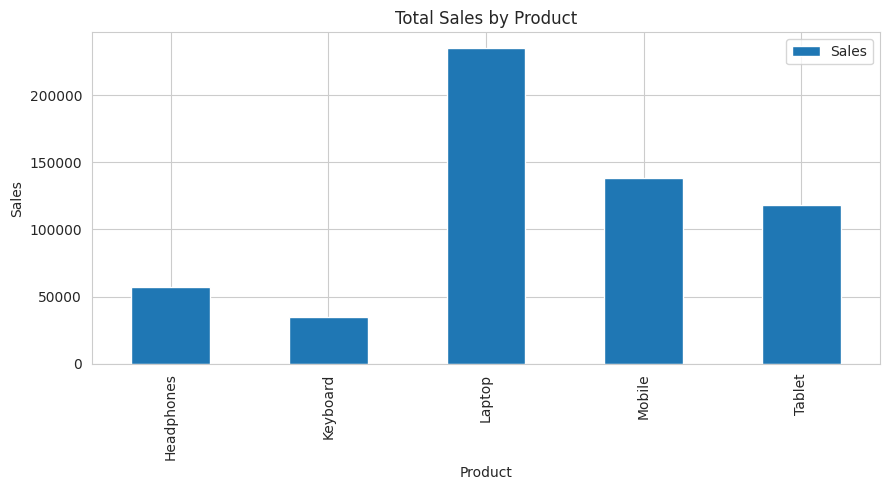

In [30]:
analyzer.visualize_data("bar")

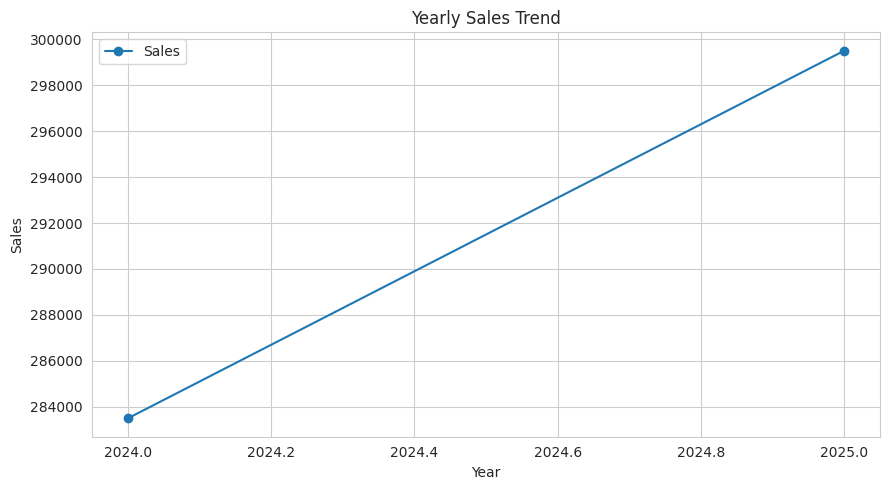

In [31]:
analyzer.visualize_data("line")

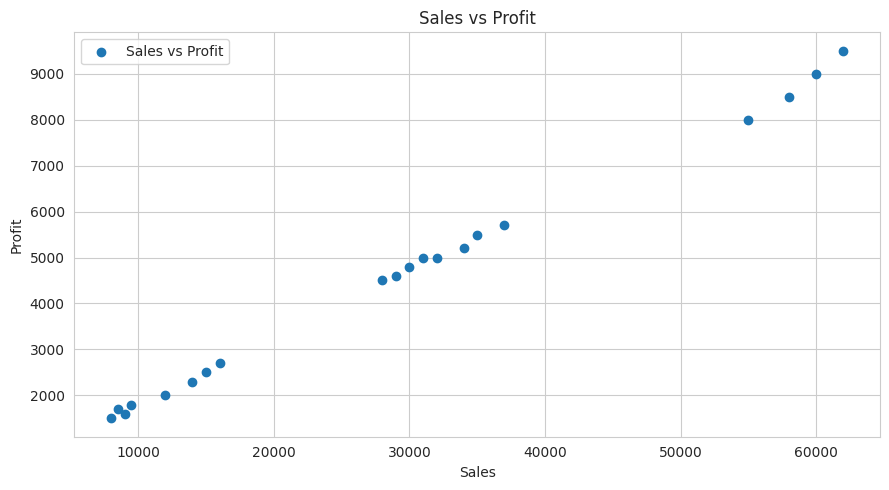

In [32]:
analyzer.visualize_data("scatter")

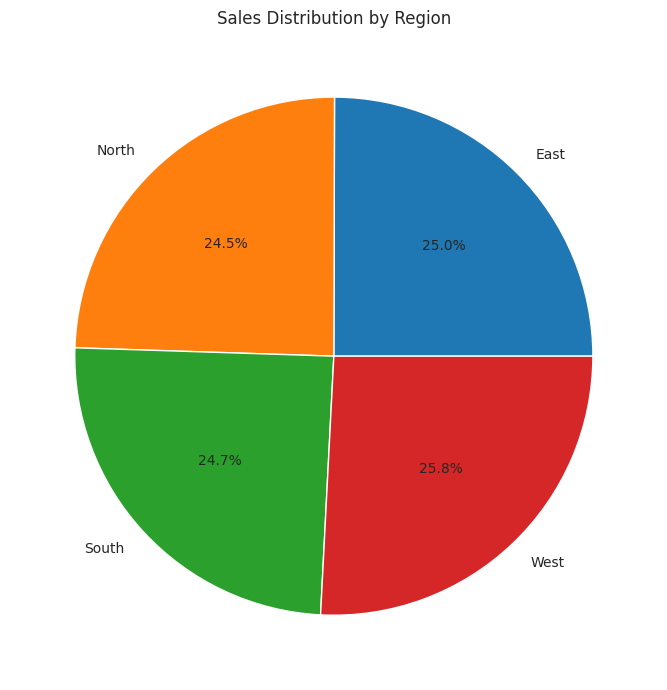

In [33]:
analyzer.visualize_data("pie")

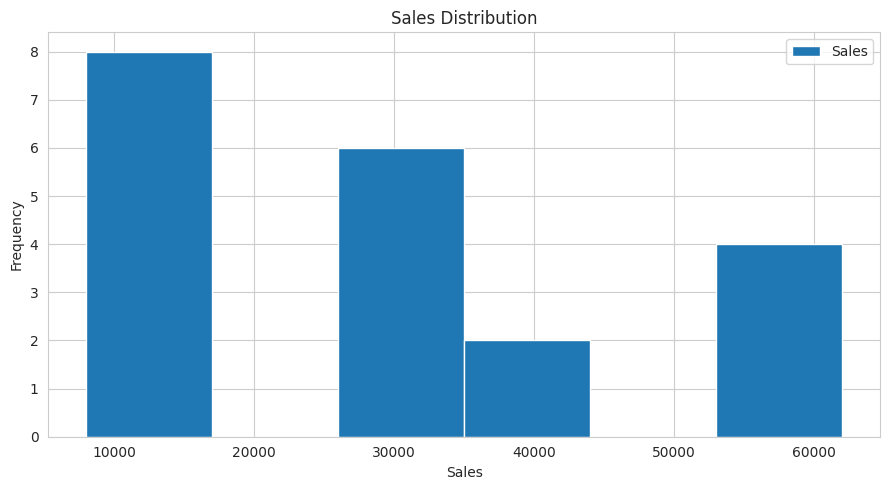

In [34]:
analyzer.visualize_data("histogram")

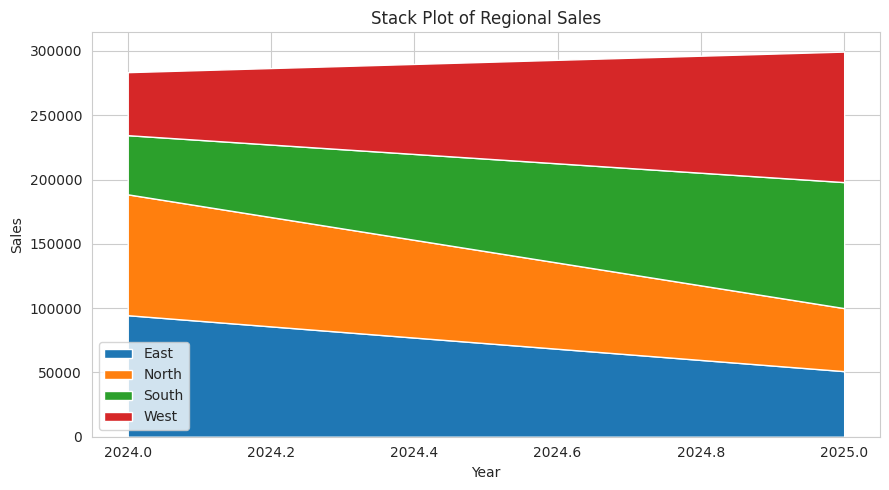

In [35]:
analyzer.visualize_data("stack")

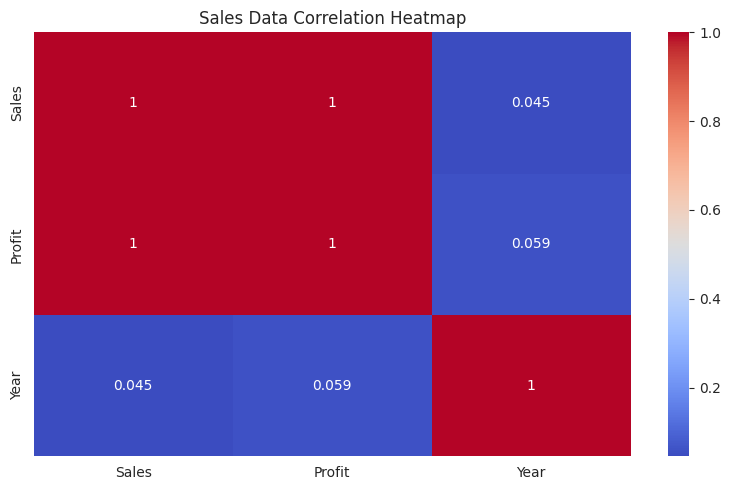

In [36]:
analyzer.visualize_data("heatmap")

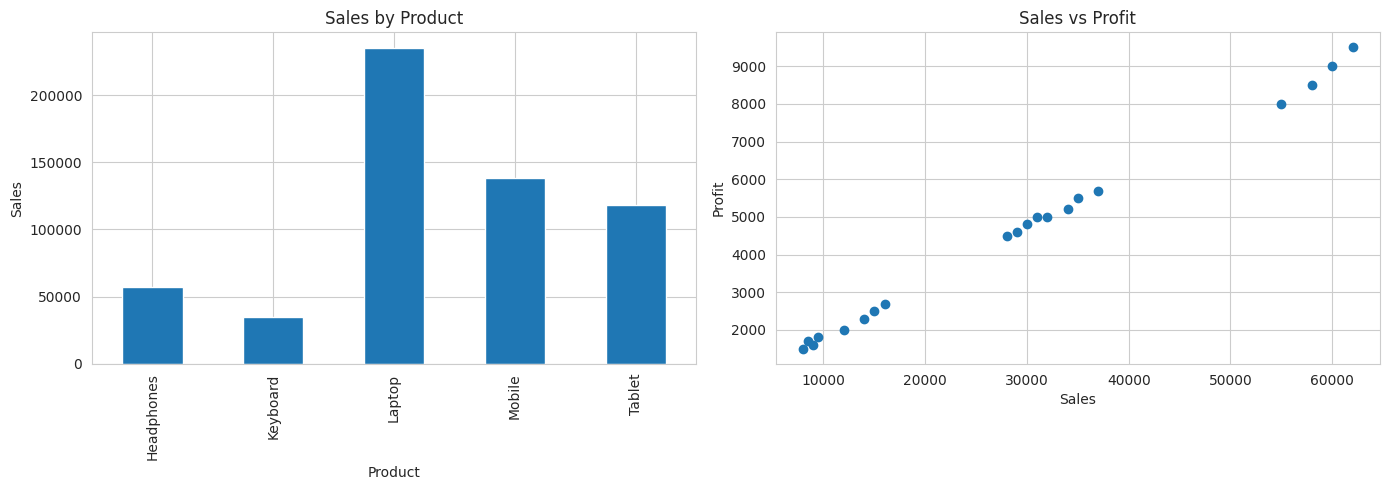

In [37]:
analyzer.visualize_data("subplots")

In [38]:
analyzer.save_visualization("sales_visualization.png")

Visualization saved successfully!
File: sales_visualization.png


In [39]:
analyzer.save_visualization("sales_visualization.jpeg")

Visualization saved successfully!
File: sales_visualization.jpeg


In [40]:
analyzer.export_analysis()

Analysis results exported successfully!
File: analysis_results.csv


In [41]:
def main_menu(analyzer):

    while True:

        print("\n==============================================")
        print("       PANDAS ANALYZER & DATA VISUALIZATION")
        print("==============================================")
        print("1. Load Dataset")
        print("2. Explore Data")
        print("3. Perform DataFrame Operations")
        print("4. Handle Missing Data")
        print("5. Generate Descriptive Statistics")
        print("6. Data Visualization")
        print("7. Save Visualization")
        print("8. Exit")
        print("==============================================")

        choice = input("Enter your choice: ")

        if choice == "1":
            file_path = input("Enter CSV file path: ")
            analyzer.load_data(file_path)

        elif choice == "2":
            analyzer.explore_data()

        elif choice == "3":
            analyzer.dataframe_operations()

        elif choice == "4":

            while True:

                print("\n---------- MISSING DATA MENU ----------")
                print("1. Display rows with missing values")
                print("2. Fill missing values with mean")
                print("3. Drop rows with missing values")
                print("4. Replace missing values with specific value")
                print("5. Back to Main Menu")

                missing_choice = input("Enter your choice: ")

                if missing_choice == "1":

                    missing_rows = analyzer.data[
                        analyzer.data.isnull().any(axis=1)
                    ]

                    if missing_rows.empty:
                        print("No missing values found.")
                    else:
                        display(missing_rows)

                elif missing_choice == "2":
                    analyzer.clean_data()

                elif missing_choice == "3":

                    before = len(analyzer.data)

                    analyzer.data.dropna(inplace=True)

                    after = len(analyzer.data)

                    print(
                        f"{before - after} rows containing missing values were removed."
                    )

                elif missing_choice == "4":

                    column = input("Enter column name: ")
                    value = input("Enter replacement value: ")

                    if column in analyzer.data.columns:

                        analyzer.data[column] = analyzer.data[column].fillna(value)

                        print("Missing values replaced successfully.")

                    else:
                        print("Column not found.")

                elif missing_choice == "5":
                    break

                else:
                    print("Invalid choice.")

        elif choice == "5":
            analyzer.statistical_analysis()

        elif choice == "6":

            while True:

                print("\n---------- VISUALIZATION MENU ----------")
                print("1. Bar Chart")
                print("2. Line Chart")
                print("3. Scatter Plot")
                print("4. Pie Chart")
                print("5. Histogram")
                print("6. Stack Plot")
                print("7. Heatmap")
                print("8. Box Plot")
                print("9. Subplots")
                print("10. Back to Main Menu")

                chart_choice = input("Enter your choice: ")

                chart_types = {
                    "1": "bar",
                    "2": "line",
                    "3": "scatter",
                    "4": "pie",
                    "5": "histogram",
                    "6": "stack",
                    "7": "heatmap",
                    "8": "box",
                    "9": "subplots"
                }

                if chart_choice in chart_types:
                    analyzer.visualize_data(chart_types[chart_choice])

                elif chart_choice == "10":
                    break

                else:
                    print("Invalid choice.")

        elif choice == "7":

            file_name = input(
                "Enter file name (.png or .jpeg): "
            )

            analyzer.save_visualization(file_name)

            export_choice = input(
                "Do you want to export analysis results? (y/n): "
            )

            if export_choice.lower() == "y":
                analyzer.export_analysis()

        elif choice == "8":

            print("\nExiting the program...")

            analyzer.conclusion()

            print("\nThank you for using Pandas Analyzer!")
            print("==============================================")

            break

        else:
            print("Invalid choice. Please try again.")

In [42]:
main_menu(analyzer)


       PANDAS ANALYZER & DATA VISUALIZATION
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit
Enter your choice: 8

Exiting the program...

========== PROJECT CONCLUSION ==========
Total Sales: 583000
Total Profit: 91400
Best Performing Product: Laptop
Best Performing Region: West

The sales dataset was successfully explored, cleaned, analyzed and visualized.
Pandas, NumPy, Matplotlib and Seaborn operations were successfully demonstrated.

Thank you for using Pandas Analyzer!
